# Actor-Critic for Defensive Chess

In this notebook, we will:
- define what a defensive chess policy should optimize in full-board training,
- build a Gym-compatible environment that always trains on legal full-board positions,
- use a masked actor-critic model so the policy only assigns probability to legal moves,
- train against a stronger heuristic attacker designed for long full-board games,
- and evaluate whether the learned defender survives pressure more reliably than a random legal-move baseline.

## 1. What “defensive chess” means here

A defensive chess policy has to do more than dodge one tactic. It needs to survive over many plies while the position keeps changing.

In this notebook, black is rewarded for:
- staying alive for longer,
- preserving material,
- reducing immediate king danger,
- keeping pieces defended instead of hanging,
- maintaining enough mobility to avoid getting squeezed,
- and improving practical safety, such as castling into shelter when possible.

In [1]:
!pip install -q python-chess gymnasium torch matplotlib pandas numpy

In [2]:
from __future__ import annotations

import random
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Tuple

import chess
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium import spaces
from IPython.display import display
from torch.distributions import Categorical

SEED = 11
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

@dataclass
class NotebookConfig:
    train_episodes: int = 10000 # You can use a smaller number for shorter training time
    eval_episodes: int = 50
    gamma: float = 0.99
    learning_rate: float = 1e-3
    entropy_coef: float = 0.015
    value_coef: float = 0.5
    hidden_dim: int = 256
    max_full_game_plies: int = 32
    survival_reward: float = 0.15
    material_weight: float = 0.25
    king_danger_weight: float = 0.12
    attacked_piece_weight: float = 0.06
    check_penalty: float = 0.5
    mobility_weight: float = 0.02
    center_pressure_weight: float = 0.03
    castling_bonus: float = 0.2
    min_plies_before_mercy: int = 12
    mercy_material_threshold: float = -9.0
    mercy_king_danger_threshold: float = 6.0
    evaluation_print_games: int = 2
    checkpoint_interval: int = 50
    opening_book_prefixes: List[List[str]] = field(default_factory=lambda: [
        ["e4"],
        ["d4"],
        ["c4"],
        ["Nf3"],
        ["e4", "e5", "Nf3"],
        ["d4", "Nf6", "c4"],
        ["c4", "e5", "Nc3"],
        ["Nf3", "d5", "g3"],
    ])

CONFIG = NotebookConfig()
ARTIFACT_DIR = Path("artifacts")
MODEL_PATH = ARTIFACT_DIR / "full_board_defensive_actor_critic.pt"
CHECKPOINT_PATH = ARTIFACT_DIR / "full_board_defensive_actor_critic_checkpoint.pt"
HISTORY_PATH = ARTIFACT_DIR / "full_board_defensive_actor_critic_history.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(CONFIG)
print(f"Using device: {DEVICE}")

NotebookConfig(train_episodes=10000, eval_episodes=50, gamma=0.99, learning_rate=0.001, entropy_coef=0.015, value_coef=0.5, hidden_dim=256, max_full_game_plies=32, survival_reward=0.15, material_weight=0.25, king_danger_weight=0.12, attacked_piece_weight=0.06, check_penalty=0.5, mobility_weight=0.02, center_pressure_weight=0.03, castling_bonus=0.2, min_plies_before_mercy=12, mercy_material_threshold=-9.0, mercy_king_danger_threshold=6.0, evaluation_print_games=2, checkpoint_interval=50, opening_book_prefixes=[['e4'], ['d4'], ['c4'], ['Nf3'], ['e4', 'e5', 'Nf3'], ['d4', 'Nf6', 'c4'], ['c4', 'e5', 'Nc3'], ['Nf3', 'd5', 'g3']])
Using device: cuda


## 2. Why actor-critic fits here

Training a defensive chess policy has several challenges:
- the set of legal actions changes from position to position,
- rewards often arrive after several moves rather than immediately,
- and short-term tactical safety can conflict with longer-term piece coordination.

Actor-critic is a natural fit:
- The **actor** represents a stochastic policy over legal moves.
- The **critic** estimates how promising the current position is for black.
- The **advantage** tells us whether the chosen move produced a better or worse outcome than expected.

We keep a small custom training loop rather than importing a higher-level RL package because chess needs **legal-action masking** over a large discrete move vocabulary. The code remains close to the familiar Gym-plus-PyTorch recipe: collect trajectories, compute returns, compute advantages, and update actor and critic together.

### Why the opponent policy matters

The quality of the attacking side shapes the quality of the training signal. If white plays aimlessly, black can collect reward without learning robust defensive habits.

For that reason, this notebook uses a heuristic attacker that values:
- mating threats and checks,
- winning material,
- increasing black king danger,
- developing pieces into active squares,
- and raising pressure in the center and around the king.

This is not an engine, but it creates a far more meaningful training signal for long episodes.

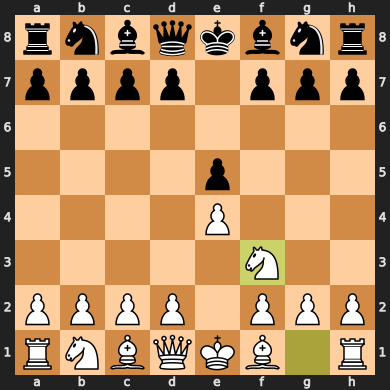

♜ ♞ ♝ ♛ ♚ ♝ ♞ ♜
♟ ♟ ♟ ♟ ⭘ ♟ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♟ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♙ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♘ ⭘ ⭘
♙ ♙ ♙ ♙ ⭘ ♙ ♙ ♙
♖ ♘ ♗ ♕ ♔ ♗ ⭘ ♖
Observation size: 775
Action vocabulary size: 5056
Heuristic white reply from the sample board: a7a6


In [3]:
PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.0,
    chess.BISHOP: 3.25,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
    chess.KING: 0.0,
}

PROMOTIONS = [None, chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT]
CENTER_SQUARES = [chess.D4, chess.E4, chess.D5, chess.E5]
HOME_MINOR_SQUARES = {
    chess.WHITE: {chess.B1, chess.G1, chess.C1, chess.F1},
    chess.BLACK: {chess.B8, chess.G8, chess.C8, chess.F8},
}

def build_move_vocabulary() -> List[str]:
    moves = set()
    for from_square in chess.SQUARES:
        for to_square in chess.SQUARES:
            if from_square == to_square:
                continue
            moves.add(chess.Move(from_square, to_square).uci())
            from_rank = chess.square_rank(from_square)
            to_rank = chess.square_rank(to_square)
            if from_rank in (1, 6) and to_rank in (0, 7):
                for promotion in PROMOTIONS[1:]:
                    moves.add(chess.Move(from_square, to_square, promotion=promotion).uci())
    return sorted(moves)

MOVE_VOCAB = build_move_vocabulary()
MOVE_TO_INDEX = {uci: idx for idx, uci in enumerate(MOVE_VOCAB)}

def move_to_index(move: chess.Move) -> int:
    return MOVE_TO_INDEX[move.uci()]

def legal_action_mask(board: chess.Board) -> np.ndarray:
    mask = np.zeros(len(MOVE_VOCAB), dtype=np.float32)
    for move in board.legal_moves:
        mask[move_to_index(move)] = 1.0
    return mask

def board_material(board: chess.Board, color: chess.Color) -> float:
    total = 0.0
    for piece_type, value in PIECE_VALUES.items():
        total += len(board.pieces(piece_type, color)) * value
    return total

def count_attacked_pieces(board: chess.Board, color: chess.Color) -> int:
    attacked = 0
    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type != chess.KING and board.is_attacked_by(not color, square):
            attacked += 1
    return attacked

def king_danger(board: chess.Board, color: chess.Color) -> int:
    king_square = board.king(color)
    if king_square is None:
        return 100
    neighborhood = chess.SquareSet(chess.BB_KING_ATTACKS[king_square] | chess.BB_SQUARES[king_square])
    return sum(1 for square in neighborhood if board.is_attacked_by(not color, square))

def legal_move_count_for(board: chess.Board, color: chess.Color) -> int:
    probe = board.copy(stack=False)
    probe.turn = color
    return probe.legal_moves.count()

def center_pressure(board: chess.Board, attacker: chess.Color, defender: chess.Color = chess.BLACK) -> int:
    king_square = board.king(defender)
    pressure = 0
    for square in CENTER_SQUARES:
        if board.is_attacked_by(attacker, square):
            pressure += 1
    if king_square is not None:
        king_file = chess.square_file(king_square)
        for square in CENTER_SQUARES:
            if abs(chess.square_file(square) - king_file) <= 1 and board.is_attacked_by(attacker, square):
                pressure += 1
    return pressure

def has_castled(board: chess.Board, color: chess.Color) -> float:
    king_square = board.king(color)
    if color == chess.BLACK:
        return float(king_square in (chess.G8, chess.C8))
    return float(king_square in (chess.G1, chess.C1))

def developed_minor_pieces(board: chess.Board, color: chess.Color) -> int:
    developed = 0
    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type in (chess.KNIGHT, chess.BISHOP) and square not in HOME_MINOR_SQUARES[color]:
            developed += 1
    return developed

def encode_board(board: chess.Board, perspective: chess.Color = chess.BLACK) -> np.ndarray:
    planes = np.zeros((12, 8, 8), dtype=np.float32)
    for square, piece in board.piece_map().items():
        row = 7 - chess.square_rank(square)
        col = chess.square_file(square)
        if perspective == chess.BLACK:
            row = 7 - row
            col = 7 - col
        color_offset = 0 if piece.color == perspective else 6
        plane_idx = color_offset + piece.piece_type - 1
        planes[plane_idx, row, col] = 1.0
    metadata = np.array([
        float(board.turn == perspective),
        float(board.has_kingside_castling_rights(perspective)),
        float(board.has_queenside_castling_rights(perspective)),
        float(board.has_kingside_castling_rights(not perspective)),
        float(board.has_queenside_castling_rights(not perspective)),
        has_castled(board, perspective),
        has_castled(board, not perspective),
    ], dtype=np.float32)
    return np.concatenate([planes.reshape(-1), metadata])

def build_opening_board(prefix: List[str]) -> chess.Board:
    board = chess.Board()
    for san in prefix:
        board.push_san(san)
    if board.turn != chess.BLACK:
        raise ValueError(f"Opening prefix must leave black to move: {prefix}")
    return board

def defensive_score(board: chess.Board, defender_color: chess.Color = chess.BLACK) -> Dict[str, float]:
    own_material = board_material(board, defender_color)
    opp_material = board_material(board, not defender_color)
    material_balance = own_material - opp_material
    return {
        "material_balance": material_balance,
        "attacked_pieces": float(count_attacked_pieces(board, defender_color)),
        "king_danger": float(king_danger(board, defender_color)),
        "in_check": float(board.is_check() and board.turn == defender_color),
        "mobility": float(legal_move_count_for(board, defender_color)),
        "center_pressure": float(center_pressure(board, not defender_color, defender_color)),
        "castled": has_castled(board, defender_color),
    }

def reward_breakdown(before: chess.Board, after: chess.Board, config: NotebookConfig, defender_color: chess.Color = chess.BLACK) -> Dict[str, float]:
    before_score = defensive_score(before, defender_color)
    after_score = defensive_score(after, defender_color)
    parts = {
        "survival": config.survival_reward,
        "material": config.material_weight * (after_score["material_balance"] - before_score["material_balance"]),
        "king_safety": -config.king_danger_weight * (after_score["king_danger"] - before_score["king_danger"]),
        "attacked_pieces": -config.attacked_piece_weight * (after_score["attacked_pieces"] - before_score["attacked_pieces"]),
        "in_check": -config.check_penalty * after_score["in_check"],
        "mobility": config.mobility_weight * (after_score["mobility"] - before_score["mobility"]),
        "center_pressure": -config.center_pressure_weight * (after_score["center_pressure"] - before_score["center_pressure"]),
        "castling": config.castling_bonus * (after_score["castled"] - before_score["castled"]),
        "checkmate": -10.0 if after.is_checkmate() else 0.0,
    }
    parts["total"] = sum(parts.values())
    return parts

def white_attack_score(before: chess.Board, after: chess.Board) -> float:
    score = 0.0
    defender_color = chess.BLACK
    material_gain = board_material(before, defender_color) - board_material(after, defender_color)
    danger_gain = king_danger(after, defender_color) - king_danger(before, defender_color)
    attacked_gain = count_attacked_pieces(after, defender_color) - count_attacked_pieces(before, defender_color)
    development_gain = developed_minor_pieces(after, chess.WHITE) - developed_minor_pieces(before, chess.WHITE)
    center_gain = center_pressure(after, chess.WHITE, defender_color) - center_pressure(before, chess.WHITE, defender_color)
    score += 1000.0 if after.is_checkmate() else 0.0
    score += 35.0 if after.is_check() else 0.0
    score += 18.0 * material_gain
    score += 4.0 * danger_gain
    score += 2.0 * attacked_gain
    score += 1.5 * development_gain
    score += 1.2 * center_gain
    score += 1.0 * (has_castled(after, chess.WHITE) - has_castled(before, chess.WHITE))
    return score

def aggressive_white_move(board: chess.Board) -> chess.Move:
    legal_moves = list(board.legal_moves)
    scored_moves = []
    for move in legal_moves:
        candidate = board.copy(stack=False)
        candidate.push(move)
        score = white_attack_score(board, candidate)
        scored_moves.append((score, move.uci(), move))
    scored_moves.sort(key=lambda item: (-item[0], item[1]))
    return scored_moves[0][2]

OBSERVATION_SIZE = encode_board(chess.Board()).shape[0]
sample_board = build_opening_board(["e4", "e5", "Nf3"])
display(sample_board)
print(sample_board.unicode())
print(f"Observation size: {OBSERVATION_SIZE}")
print(f"Action vocabulary size: {len(MOVE_VOCAB)}")
print("Heuristic white reply from the sample board:", aggressive_white_move(sample_board).uci())

## 3. State, action, reward, and episode design

**State.** We encode the full board as piece planes plus metadata such as side to move, castling rights, and castled status.

**Action.** The policy works in a global UCI move vocabulary. A legal-action mask removes impossible moves at each position.

**Reward.** The reward combines a defensive core with terms that matter more over longer horizons:
- survival,
- material balance,
- king danger,
- hanging pieces,
- staying out of check,
- mobility,
- central pressure by white,
- and successful castling.

**Episode.** Each episode starts from a legal full-board opening prefix and then alternates black's learned move with white's heuristic attacking reply until the game ends or the configured ply budget runs out.

The environment also includes a small mercy-stop rule. If black is already deeply lost and under major pressure after enough plies, the episode can truncate early so training time is not wasted on hopeless tails.

In [4]:
class FullBoardDefensiveChessEnv(gym.Env):
    metadata = {"render_modes": ["unicode"]}

    def __init__(self, config: NotebookConfig, split: str = "train"):
        super().__init__()
        self.config = config
        self.split = split
        self.defender_color = chess.BLACK
        self.action_space = spaces.Discrete(len(MOVE_VOCAB))
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(OBSERVATION_SIZE,), dtype=np.float32)
        self.board = chess.Board()
        self.current_step = 0
        self.plies_played = 0
        self.opening_prefix: List[str] = []

    def _select_board(self) -> Tuple[chess.Board, List[str]]:
        prefix = random.choice(self.config.opening_book_prefixes)
        return build_opening_board(prefix), prefix

    def _get_obs(self) -> np.ndarray:
        return encode_board(self.board, perspective=self.defender_color)

    def _should_mercy_stop(self) -> bool:
        if self.plies_played < self.config.min_plies_before_mercy:
            return False
        score = defensive_score(self.board, self.defender_color)
        return (
            score["material_balance"] <= self.config.mercy_material_threshold
            and score["king_danger"] >= self.config.mercy_king_danger_threshold
        )

    def reset(self, *, seed: int | None = None, options: dict | None = None):
        super().reset(seed=seed)
        self.board, self.opening_prefix = self._select_board()
        self.current_step = 0
        self.plies_played = len(self.opening_prefix)
        info = {
            "opening_prefix": self.opening_prefix,
            "fen": self.board.fen(),
            "legal_mask": legal_action_mask(self.board),
            "board": self.board.copy(stack=False),
        }
        return self._get_obs(), info

    def step(self, action: int):
        if self.board.is_game_over():
            raise RuntimeError("Call reset() before stepping a finished episode.")

        self.current_step += 1
        before = self.board.copy(stack=False)
        proposed = chess.Move.from_uci(MOVE_VOCAB[action])
        legal_moves = list(self.board.legal_moves)
        used_illegal_fallback = False
        if proposed not in legal_moves:
            proposed = random.choice(legal_moves)
            used_illegal_fallback = True
        self.board.push(proposed)
        self.plies_played += 1

        if not self.board.is_game_over() and self.plies_played < self.config.max_full_game_plies:
            reply = aggressive_white_move(self.board)
            self.board.push(reply)
            self.plies_played += 1
        else:
            reply = None

        breakdown = reward_breakdown(before, self.board, self.config, defender_color=self.defender_color)
        terminated = self.board.is_game_over()
        mercy_stop = False if terminated else self._should_mercy_stop()
        truncated = self.plies_played >= self.config.max_full_game_plies or mercy_stop
        info = {
            "opening_prefix": self.opening_prefix,
            "fen": self.board.fen(),
            "agent_move": proposed.uci(),
            "opponent_move": reply.uci() if reply else None,
            "illegal_fallback": used_illegal_fallback,
            "mercy_stop": mercy_stop,
            "reward_parts": breakdown,
            "legal_mask": legal_action_mask(self.board) if not (terminated or truncated) else np.zeros(len(MOVE_VOCAB), dtype=np.float32),
            "board": self.board.copy(stack=False),
        }
        return self._get_obs(), breakdown["total"], terminated, truncated, info

    def render(self):
        print(self.board.unicode())

env = FullBoardDefensiveChessEnv(CONFIG, split="train")
obs, info = env.reset()
print("Opening prefix:", info["opening_prefix"])
print("Observation shape:", obs.shape)
print("Legal moves available:", int(info["legal_mask"].sum()))
env.render()

Opening prefix: ['Nf3', 'd5', 'g3']
Observation shape: (775,)
Legal moves available: 28
♜ ♞ ♝ ♛ ♚ ♝ ♞ ♜
♟ ♟ ♟ ⭘ ♟ ♟ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ♟ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♘ ♙ ⭘
♙ ♙ ♙ ♙ ♙ ♙ ⭘ ♙
♖ ♘ ♗ ♕ ♔ ♗ ⭘ ♖


## 4. Training the actor and critic

The model uses two heads:
- an **actor head** for move logits over the full move vocabulary,
- and a **critic head** for the expected return.

Training unfolds over longer games with more delayed feedback, so we keep entropy regularization, value loss, and gradient clipping to make optimization more stable.

Legal-action masking is the chess-specific trick. Illegal logits are replaced with a very large negative number so the categorical policy assigns them effectively zero probability.

In [5]:
class MaskedActorCritic(nn.Module):
    def __init__(self, observation_size: int, action_size: int, hidden_dim: int = 256):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(observation_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.policy_head = nn.Linear(hidden_dim, action_size)
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, obs: torch.Tensor, mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        features = self.backbone(obs)
        logits = self.policy_head(features)
        masked_logits = logits.masked_fill(mask <= 0, -1e9)
        value = self.value_head(features).squeeze(-1)
        return masked_logits, value

def discounted_returns(rewards: List[float], gamma: float) -> torch.Tensor:
    returns = []
    running = 0.0
    for reward in reversed(rewards):
        running = reward + gamma * running
        returns.append(running)
    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)

def rollout_episode(env: FullBoardDefensiveChessEnv, model: MaskedActorCritic, greedy: bool = False):
    obs, info = env.reset()
    done = False
    trajectory = []
    total_reward = 0.0
    boards = [info["board"]]
    move_trace = []
    illegal_count = 0
    while not done:
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        mask_tensor = torch.tensor(info["legal_mask"], dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits, value = model(obs_tensor, mask_tensor)
        dist = Categorical(logits=logits)
        action = torch.argmax(logits, dim=-1) if greedy else dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        next_obs, reward, terminated, truncated, next_info = env.step(action.item())
        illegal_count += int(next_info["illegal_fallback"])
        move_trace.append((next_info["agent_move"], next_info["opponent_move"]))
        trajectory.append({
            "obs": obs_tensor.squeeze(0),
            "mask": mask_tensor.squeeze(0),
            "action": action.squeeze(0),
            "log_prob": log_prob.squeeze(0),
            "entropy": entropy.squeeze(0),
            "value": value.squeeze(0),
            "reward": reward,
            "info": next_info,
        })
        total_reward += reward
        done = terminated or truncated
        obs, info = next_obs, next_info
        boards.append(next_info["board"])
    return trajectory, total_reward, boards, move_trace, illegal_count

def build_training_payload(model: MaskedActorCritic, config: NotebookConfig, episode: int | None = None, optimizer: torch.optim.Optimizer | None = None, history: pd.DataFrame | None = None):
    payload = {
        "model_state_dict": model.state_dict(),
        "observation_size": OBSERVATION_SIZE,
        "action_size": len(MOVE_VOCAB),
        "hidden_dim": config.hidden_dim,
        "max_full_game_plies": config.max_full_game_plies,
        "opening_book_prefixes": config.opening_book_prefixes,
    }
    if episode is not None:
        payload["episode"] = episode
    if optimizer is not None:
        payload["optimizer_state_dict"] = optimizer.state_dict()
    if history is not None:
        payload["history"] = history.to_dict(orient="records")
    return payload

def save_training_checkpoint(model: MaskedActorCritic, optimizer: torch.optim.Optimizer, history: pd.DataFrame, config: NotebookConfig, episode: int):
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(build_training_payload(model, config, episode=episode, optimizer=optimizer, history=history), CHECKPOINT_PATH)

def save_training_artifacts(model: MaskedActorCritic, history: pd.DataFrame, config: NotebookConfig):
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(build_training_payload(model, config), MODEL_PATH)
    history.to_csv(HISTORY_PATH, index=False)

def load_training_artifacts(config: NotebookConfig):
    if not MODEL_PATH.exists() or not HISTORY_PATH.exists():
        return None, None
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    loaded_model = MaskedActorCritic(
        checkpoint["observation_size"],
        checkpoint["action_size"],
        hidden_dim=checkpoint.get("hidden_dim", config.hidden_dim),
    ).to(DEVICE)
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model.eval()
    loaded_history = pd.read_csv(HISTORY_PATH)
    return loaded_model, loaded_history

def train_actor_critic(config: NotebookConfig, save_artifacts: bool = True):
    env = FullBoardDefensiveChessEnv(config, split="train")
    model = MaskedActorCritic(OBSERVATION_SIZE, len(MOVE_VOCAB), hidden_dim=config.hidden_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    history = []
    for episode in range(1, config.train_episodes + 1):
        trajectory, total_reward, _, _, illegal_count = rollout_episode(env, model, greedy=False)
        returns = discounted_returns([step["reward"] for step in trajectory], config.gamma)
        log_probs = torch.stack([step["log_prob"] for step in trajectory])
        entropies = torch.stack([step["entropy"] for step in trajectory])
        values = torch.stack([step["value"] for step in trajectory])
        advantages = returns - values.detach()

        policy_loss = -(log_probs * advantages).mean()
        value_loss = F.mse_loss(values, returns)
        entropy_bonus = entropies.mean()
        loss = policy_loss + config.value_coef * value_loss - config.entropy_coef * entropy_bonus

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        history.append({
            "episode": episode,
            "reward": total_reward,
            "policy_loss": float(policy_loss.detach().cpu()),
            "value_loss": float(value_loss.detach().cpu()),
            "entropy": float(entropy_bonus.detach().cpu()),
            "illegal_fallbacks": illegal_count,
        })
        if save_artifacts and config.checkpoint_interval > 0 and episode % config.checkpoint_interval == 0:
            checkpoint_history = pd.DataFrame(history)
            save_training_checkpoint(model, optimizer, checkpoint_history, config, episode)
    history_df = pd.DataFrame(history)
    if save_artifacts:
        save_training_checkpoint(model, optimizer, history_df, config, config.train_episodes)
        save_training_artifacts(model, history_df, config)
    return model, history_df

model, history = train_actor_critic(CONFIG)
history.tail()

,episode,reward,policy_loss,value_loss,entropy,illegal_fallbacks
9995,9996,6.0025,0.014976,0.007943,0.130950,0
9996,9997,8.5025,0.000212,0.008038,0.092058,0
9997,9998,7.2100,-0.055665,0.047274,0.140829,0
9998,9999,6.0025,-0.001085,0.012902,0.061020,0
9999,10000,8.5025,-0.001449,0.016033,0.094348,0


## 5. Reward design tradeoffs

Reward design for defensive chess can be easy to get wrong.

Some common failure modes are:
- **Too tactical**: the agent learns to survive one move but drifts into strategically bad positions.
- **Too material-heavy**: the agent clings to material but leaves the king unsafe.
- **Too safety-heavy**: the agent shuffles pieces passively and gives white a free attack.
- **Too many bonuses**: the agent optimizes the reward formula rather than practical defense.

A good debugging habit is to inspect candidate moves before trusting the training loop. The next cell scores a handful of legal replies from an opening position so we can see whether the reward roughly prefers the kind of defensive moves we intended.

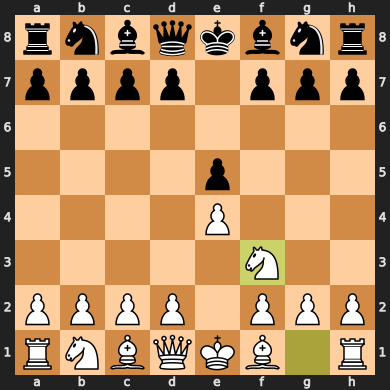

♜ ♞ ♝ ♛ ♚ ♝ ♞ ♜
♟ ♟ ♟ ♟ ⭘ ♟ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♟ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♙ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♘ ⭘ ⭘
♙ ♙ ♙ ♙ ⭘ ♙ ♙ ♙
♖ ♘ ♗ ♕ ♔ ♗ ⭘ ♖


,move,survival,material,king_safety,attacked_pieces,in_check,mobility,center_pressure,castling,checkmate,total
10,d8f6,0.15,-0.25,-0.24,-0.06,-0.0,0.20,0.12,0.0,0.0,-0.08
5,f8c5,0.15,-0.25,-0.24,-0.06,-0.0,0.08,0.12,0.0,0.0,-0.20
6,f8b4,0.15,-0.25,-0.24,-0.06,-0.0,0.08,0.12,0.0,0.0,-0.20
28,a7a5,0.15,-0.25,-0.24,-0.06,-0.0,0.02,0.12,0.0,0.0,-0.26
20,b7b6,0.15,-0.25,-0.24,-0.06,-0.0,0.02,0.12,0.0,0.0,-0.26
13,b8c6,0.15,-0.25,-0.24,-0.12,-0.0,0.06,0.12,0.0,0.0,-0.28
24,f7f5,0.15,-0.25,-0.24,-0.06,-0.0,0.00,0.12,0.0,0.0,-0.28
9,d8e7,0.15,-0.25,-0.24,-0.06,-0.0,0.00,0.12,0.0,0.0,-0.28
4,f8d6,0.15,-0.25,-0.24,-0.06,-0.0,0.00,0.12,0.0,0.0,-0.28
1,g8h6,0.15,-0.25,-0.24,-0.06,-0.0,-0.02,0.12,0.0,0.0,-0.30


In [6]:
def inspect_candidate_moves(board: chess.Board, candidate_uci_moves: List[str], config: NotebookConfig) -> pd.DataFrame:
    rows = []
    for uci in candidate_uci_moves:
        move = chess.Move.from_uci(uci)
        if move not in board.legal_moves:
            continue
        before = board.copy(stack=False)
        after = board.copy(stack=False)
        after.push(move)
        if not after.is_game_over():
            after.push(aggressive_white_move(after))
        parts = reward_breakdown(before, after, config)
        rows.append({"move": uci, **parts})
    return pd.DataFrame(rows).sort_values("total", ascending=False)

inspection_board = build_opening_board(["e4", "e5", "Nf3"])
display(inspection_board)
print(inspection_board.unicode())
inspect_candidate_moves(inspection_board, [move.uci() for move in inspection_board.legal_moves], CONFIG).head(12)

## 6. Evaluating whether the learned defender is useful

A reward curve is not enough by itself. We evaluate the trained policy against a random legal-move baseline on separate evaluation episodes.

We track:
- total episode reward,
- plies survived,
- final material balance,
- hanging black pieces,
- king danger,
- blunder rate approximated by very negative outcomes,
- illegal fallback rate,
- and whether episodes ended in a mercy stop.

The success criterion is modest: the trained policy should outperform random play on at least some of these defensive metrics.

In [7]:
def ensure_trained_artifacts(config: NotebookConfig):
    global model, history
    if "model" in globals() and "history" in globals():
        return model, history
    loaded_model, loaded_history = load_training_artifacts(config)
    if loaded_model is not None and loaded_history is not None:
        print(f"Loaded saved model from {MODEL_PATH} and history from {HISTORY_PATH}.")
        model, history = loaded_model, loaded_history
        return model, history
    print("No in-memory or saved training artifacts were found, so the notebook is training a fresh agent before evaluation.")
    model, history = train_actor_critic(config)
    return model, history

def evaluate_policy(model: MaskedActorCritic, config: NotebookConfig, greedy: bool = True, baseline: str = "trained"):
    env = FullBoardDefensiveChessEnv(config, split="eval")
    rows = []
    examples = []
    for episode in range(config.eval_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0.0
        last_info = info
        boards = [env.board.copy(stack=False)]
        trace = []
        illegal_fallbacks = 0
        while not done:
            if baseline == "random":
                legal_indices = np.flatnonzero(info["legal_mask"] > 0)
                action = int(np.random.choice(legal_indices))
            else:
                obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                mask_tensor = torch.tensor(info["legal_mask"], dtype=torch.float32, device=DEVICE).unsqueeze(0)
                logits, _ = model(obs_tensor, mask_tensor)
                dist = Categorical(logits=logits)
                action = int(torch.argmax(logits, dim=-1).item()) if greedy else int(dist.sample().item())
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            illegal_fallbacks += int(info["illegal_fallback"])
            trace.append((info["agent_move"], info["opponent_move"]))
            done = terminated or truncated
            boards.append(info["board"])
            last_info = info
        score = defensive_score(last_info["board"], chess.BLACK)
        rows.append({
            "baseline": baseline,
            "reward": total_reward,
            "plies": env.plies_played,
            "material_balance": score["material_balance"],
            "attacked_pieces": score["attacked_pieces"],
            "king_danger": score["king_danger"],
            "mobility": score["mobility"],
            "blunder": float(total_reward < -3.0),
            "illegal_fallbacks": illegal_fallbacks,
            "mercy_stop": float(last_info["mercy_stop"]),
            "opening_prefix": " ".join(last_info["opening_prefix"]),
        })
        if len(examples) < config.evaluation_print_games:
            examples.append({
                "baseline": baseline,
                "opening_prefix": last_info["opening_prefix"],
                "boards": boards,
                "trace": trace,
                "reward": total_reward,
                "final_info": last_info,
            })
    return pd.DataFrame(rows), examples

model, history = ensure_trained_artifacts(CONFIG)
trained_eval, trained_examples = evaluate_policy(model, CONFIG, greedy=True, baseline="trained")
random_eval, random_examples = evaluate_policy(model, CONFIG, greedy=True, baseline="random")
comparison = pd.concat([trained_eval, random_eval], ignore_index=True)
comparison.groupby("baseline")[["reward", "plies", "material_balance", "attacked_pieces", "king_danger", "mobility", "blunder", "illegal_fallbacks", "mercy_stop"]].mean().round(3)

,reward,plies,material_balance,attacked_pieces,king_danger,mobility,blunder,illegal_fallbacks,mercy_stop
baseline,,,,,,,,,
random,-4.450,30.84,-13.27,1.22,2.72,17.28,0.66,0.0,0.12
trained,6.663,32.00,19.79,0.96,0.20,41.30,0.00,0.0,0.00


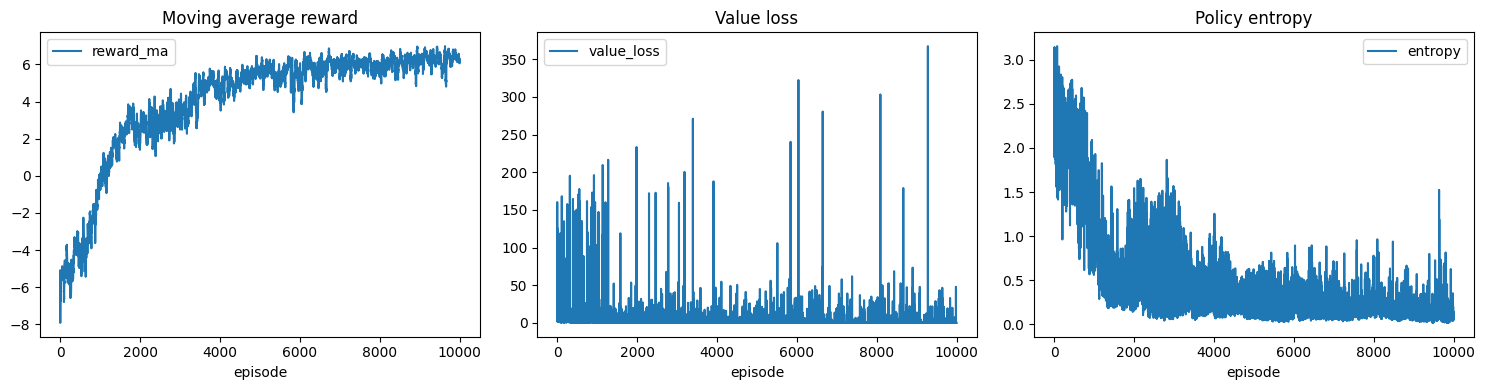

,reward,plies,material_balance,attacked_pieces,king_danger,mobility,blunder,illegal_fallbacks,mercy_stop
baseline,,,,,,,,,
random,-4.450,30.84,-13.27,1.22,2.72,17.28,0.66,0.0,0.12
trained,6.663,32.00,19.79,0.96,0.20,41.30,0.00,0.0,0.00



Example: trained | opening=d4 | reward=7.27
Initial board:
♜ ♞ ♝ ♛ ♚ ♝ ♞ ♜
♟ ♟ ♟ ♟ ♟ ♟ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ♙ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
♙ ♙ ♙ ⭘ ♙ ♙ ♙ ♙
♖ ♘ ♗ ♕ ♔ ♗ ♘ ♖
Final board:
⭘ ⭘ ♚ ♜ ⭘ ⭘ ⭘ ⭘
♟ ⭘ ⭘ ♞ ♟ ♟ ⭘ ♜
⭘ ♟ ⭘ ♛ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♟
⭘ ⭘ ♙ ♙ ⭘ ⭘ ♙ ⭘
⭘ ⭘ ⭘ ♔ ⭘ ⭘ ⭘ ⭘
♙ ♙ ⭘ ⭘ ♙ ♙ ⭘ ♙
⭘ ⭘ ⭘ ⭘ ⭘ ♗ ⭘ ♝
Move trace: [('g8h6', 'c1h6'), ('g7h6', 'b1c3'), ('h6h5', 'c3d5'), ('b7b6', 'd5c7'), ('d8c7', 'd1d3'), ('c7d8', 'd3h7'), ('h8h7', 'g1f3'), ('c8b7', 'f3e5')]
Final reward parts: {'survival': 0.15, 'material': 1.25, 'king_safety': -0.0, 'attacked_pieces': -0.0, 'in_check': -0.0, 'mobility': 0.0, 'center_pressure': -0.0, 'castling': 0.0, 'checkmate': 0.0, 'total': 1.4}

Example: random | opening=e4 e5 Nf3 | reward=-12.42
Initial board:
♜ ♞ ♝ ♛ ♚ ♝ ♞ ♜
♟ ♟ ♟ ♟ ⭘ ♟ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♟ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♙ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♘ ⭘ ⭘
♙ ♙ ♙ ♙ ⭘ ♙ ♙ ♙
♖ ♘ ♗ ♕ ♔ ♗ ⭘ ♖
Final board:
♜ ♞ ♝ ♛ ♚ ⭘ ⭘ ♜
♟ ♟ ♟ ♟ ⭘ ♕ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ♝ ⭘ ♘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♙ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
history["reward_ma"] = history["reward"].rolling(window=25, min_periods=1).mean()
history.plot(x="episode", y="reward_ma", ax=axes[0], title="Moving average reward")
history.plot(x="episode", y="value_loss", ax=axes[1], title="Value loss")
history.plot(x="episode", y="entropy", ax=axes[2], title="Policy entropy")
plt.tight_layout()
plt.show()

summary = comparison.groupby("baseline")[["reward", "plies", "material_balance", "attacked_pieces", "king_danger", "mobility", "blunder", "illegal_fallbacks", "mercy_stop"]].mean().round(3)
display(summary)

for example in trained_examples[:1] + random_examples[:1]:
    print(f"\nExample: {example['baseline']} | opening={' '.join(example['opening_prefix'])} | reward={example['reward']:.2f}")
    print("Initial board:")
    print(example["boards"][0].unicode())
    print("Final board:")
    print(example["boards"][-1].unicode())
    print("Move trace:", example["trace"][:8])
    print("Final reward parts:", example["final_info"]["reward_parts"])

## 7. Interpreting the results

If training worked, the learned defender should usually:
- earn positive movement in the defensive metrics,
- survive for more plies before collapsing,
- leave fewer pieces hanging,
- maintain lower king danger,
- and reduce obviously bad defensive collapses.

Even then, we should stay realistic. The defender is learning under a handcrafted reward and a handcrafted attacking opponent. That is useful because the notebook shows the mechanics clearly, but it is not the same as producing a tournament-strength chess policy.